In [485]:
import pandas as pd
import scipy as sp
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from scipy.stats import binomtest, ttest_ind, chi2_contingency
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import KBinsDiscretizer

train_set = pd.read_csv("train_data.csv")
train_set.head()

,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,37765,15794860,Ch'eng,627,France,Male,28.0,7,131694.04,1,1.0,1.0,161205.61,0
1,130453,15728005,Hargreaves,597,France,Male,34.0,2,0.00,2,0.0,1.0,181419.29,0
2,77297,15686810,Ts'ui,724,France,Male,39.0,7,0.00,2,1.0,1.0,100862.54,0
3,40858,15760244,Trevisano,663,Germany,Female,56.0,5,118577.24,3,1.0,0.0,61164.45,1
4,19804,15810563,French,627,France,Female,33.0,5,0.00,2,1.0,1.0,103737.82,0


Dans ce projet le jeu de test est déjà séparer en un jeu de train et de test. Le jeu de train est dans le fichier train_data.csv et le jeu de test est dans le fichier test_data.csv.

In [486]:
train_set["Exited"].value_counts()

Exited
0    113129
1     30450
Name: count, dtype: int64

On voit que les deux classes de la target sont assez désiquilibré et c'est pour cette raison qu'on utilisera la métrique f1_score. On va d'abords utiliser un modéle de régréssion logistique pour un premier modéle.

#I) Définition des variables et des lignes

•   Customer ID : Un identifiant unique pour chaque client (discret). Inutile pour le modéle.

•   Surname : Le nom de famille du client (discret). Inutile pour le modéle.

•   Credit Score : Une valeur numérique représentant le score de crédit du client (continue)

•   Geography : Le pays où réside le client (France, Spain ou Germany) (discret)

•   Gender : Le genre du client (Male or Female) (discret)

•   Age : L’âge du client (C'est une variable discréte mais qu'on va traiter comme une variable continue)

•   Tenure : Le nombre d’années pendant lesquelles le client est avec la banque (discret)

•   Balance : Le solde du compte du client (continue)

•   NumOfProducts : Le nombre de produits bancaires utilisés par le client (par exemple, compte d’épargne, carte de crédit) (discret)

•   HasCrCard : Si le client possède une carte de crédit (1 = oui, 0 = non) (discret)

•   IsActiveMember : Si le client est un membre actif (1 = oui, 0 = non) (discret)

•   EstimatedSalary : Le salaire estimé du client (continue)

•   Exited : Si le client a résilié (1 = oui, 0 = non) (discret)

•   Pour la définition des lignes, c'est les clients.

#II) Analyse statistiques

Dans cette analyse on va d'abords faire des analyses univariés de chaque variable puis bivariés avec chaque variables en fonction de la target puis on regardera les surface continue entre les variables continue.

#II.1) Analyse univarié de toutes les variables

#II.1.1) Analyse du score de crédit.

Le score de crédit est un indicateur de la capacité d'un client de payer ces dettes. Plus ce score est bas, plus le client n'est pas fiable. L'échelle et l'interprétation de ce score dépends du pays mais aussi de la banque.

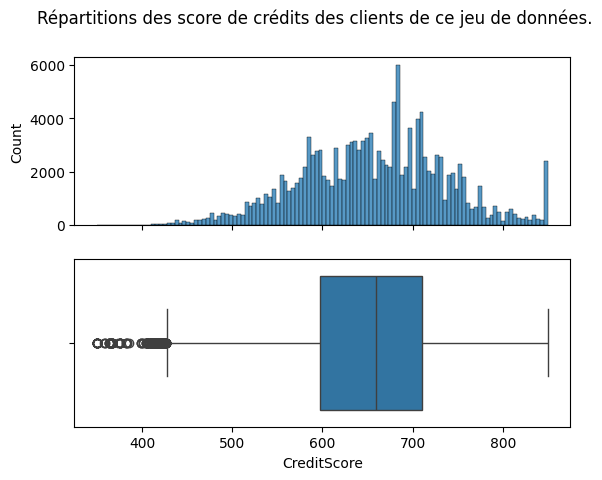

count    143579.000000
mean        656.411704
std          80.210361
min         350.000000
25%         597.000000
50%         659.000000
75%         710.000000
max         850.000000
Name: CreditScore, dtype: float64

In [487]:
fig, ax = plt.subplots(2, 1, sharex=True)
plt.suptitle("Répartitions des score de crédits des clients de ce jeu de données.")
sns.histplot(data=train_set, x="CreditScore", ax=ax[0])
sns.boxplot(data=train_set, x="CreditScore", ax=ax[1])
plt.show()
train_set["CreditScore"].describe()

On observe que la moyenne des clients qui vive en France, Allemagne et Espagne est d'environ 656. On observe que les score de crédit suive clairement une loi normale. On observe quelque outliers à gauche de la boxplot qui correspond donc au client les moins fiables. On voit aussi que la plupart des clients ont un crédit de score entre 580 et 750. C'est-à-dire que la plupart des clients ont un score de crédit plutôt moyen.


#II.1.2) Analyse du pays de résidence

On va d'abord compter le nombre de client par pays de résidence.  

In [488]:
train_set["Geography"].value_counts()

Geography
France     81886
Spain      31588
Germany    30105
Name: count, dtype: int64

On voit que la plupart des clients vive en France. Ensuite il y a un nombre similaire de client qui vive en Espagne et en Allemagne avec légéremment plus de client en Espagne qu'en Allemagne.

#II.1.3) Analyse du genre

In [489]:
train_set["Gender"].value_counts()

Gender
Male      80966
Female    62613
Name: count, dtype: int64

On voit qu'il y a plus d'homme que de femme dans cette banque.

#II.1.4) Analyse de l'âge

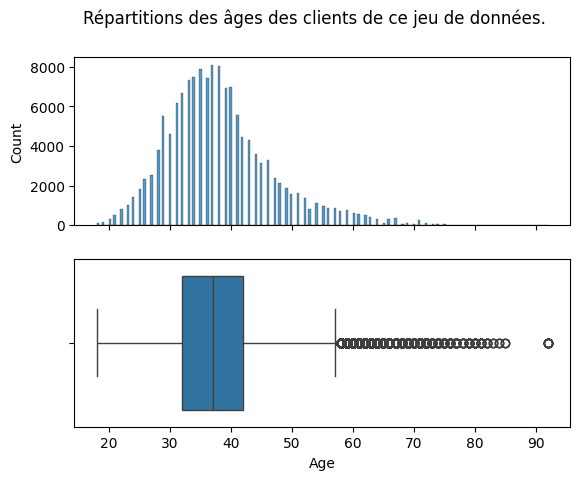

count    143579.000000
mean         38.144476
std           8.871711
min          18.000000
25%          32.000000
50%          37.000000
75%          42.000000
max          92.000000
Name: Age, dtype: float64

In [490]:
fig, ax = plt.subplots(2, 1, sharex=True)
plt.suptitle("Répartitions des âges des clients de ce jeu de données.")
sns.histplot(data=train_set, x="Age", ax=ax[0])
sns.boxplot(data=train_set, x="Age", ax=ax[1])
plt.show()
train_set["Age"].describe()

On voit que la moyenne d'âge des clients de la banque qui vivent en France, Allemagne et Espagne est de 38 ans. On voit que l'âge suit une loi normale et il y a des outliers à droite de la boxplot. On voit que la plupart des clients ont entre 30 et 40 ans.

#II.1.5) Analyse de la tenure

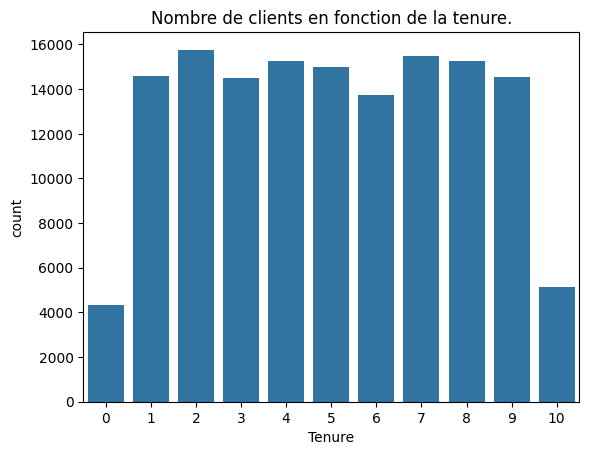

In [491]:
sns.countplot(data=train_set, x="Tenure")
plt.title("Nombre de clients en fonction de la tenure.")
plt.show()

On voit que dans la premiére année de cette banque (Tenure = 10), il y avait une quantité de client qui étais assez petites. Ensuite durant la deuxiéme (Tenure = 9), il y avait une grosse augmentation de la fréquentation de la banque et ensuite la fréquentation est relativement constante entre la deuxiéme année et la dixiéme année (Tenure = 1). Et ensuite durant l'année en cours il y a une diminution du nombre de client. Cela veut dire soit que la banque est moins attractive ou c'est tous simplement due au fait que l'année est en cours.

#II.1.6) Balance

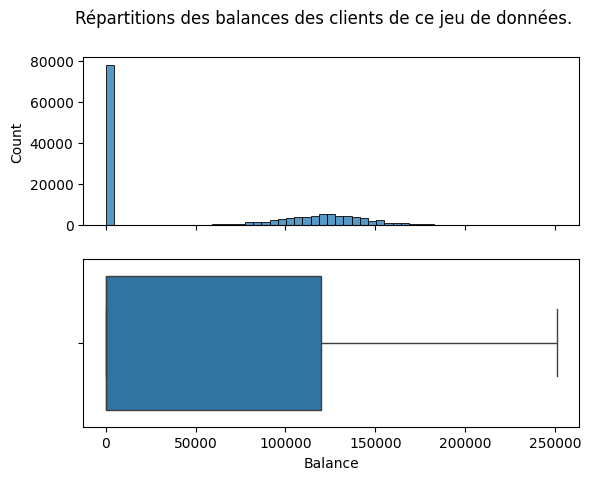

count    143579.000000
mean      55533.640642
std       62822.616346
min           0.000000
25%           0.000000
50%           0.000000
75%      119948.090000
max      250898.090000
Name: Balance, dtype: float64

In [492]:
fig, ax = plt.subplots(2, 1, sharex=True)
plt.suptitle("Répartitions des balances des clients de ce jeu de données.")
sns.histplot(data=train_set, x="Balance", ax=ax[0])
sns.boxplot(data=train_set, x="Balance", ax=ax[1])
plt.show()
train_set["Balance"].describe()

On voit que la plupart des clients ont une balance égale à 0. On voit qu'il y a une loi normale séparer des balances égales à 0. Pas d'outliers sur la boxplot. La moyenne de la balance des clients de cette banque pour les trois pays du jeu de données est d'environ 55728.70 euros.

#II.1.7) NumOfProducts

In [493]:
train_set["NumOfProducts"].value_counts()

NumOfProducts
2    73301
1    67364
3     2510
4      404
Name: count, dtype: int64

On voit que la plupart des clients ont 1 ou 2 produits et qu'il y a vraiment peu de cients qui ont 3 et 4 produit.

#II.1.8) HasCrCard

In [494]:
train_set["HasCrCard"].value_counts()

HasCrCard
1.0    108274
0.0     35305
Name: count, dtype: int64

On voit que la majorité des clients ont une carte de crédit.

#II.1.9) IsActiveMember

In [495]:
train_set["IsActiveMember"].value_counts()

IsActiveMember
0.0    72249
1.0    71330
Name: count, dtype: int64

On voit qu'il y a pratiquement autant de clients actifs que non actif. On peut donc tester cette hypothése.

In [496]:
print("H0: Il y a 50% de clients inactif.")

alpha = 0.02

p_value = binomtest(
    k=train_set["IsActiveMember"].value_counts()[1], n=len(train_set), p=0.50
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il y a 50% de clients inactif.
Nous avons assez d'évidence pour rejeter H0


Comme on n'a réussi de rejeter H0, on peut donc dire avec un risque de 2% de se trompé qu'il y a autant de client actif que inactif dans cette banque.

#II.1.10) Salaire

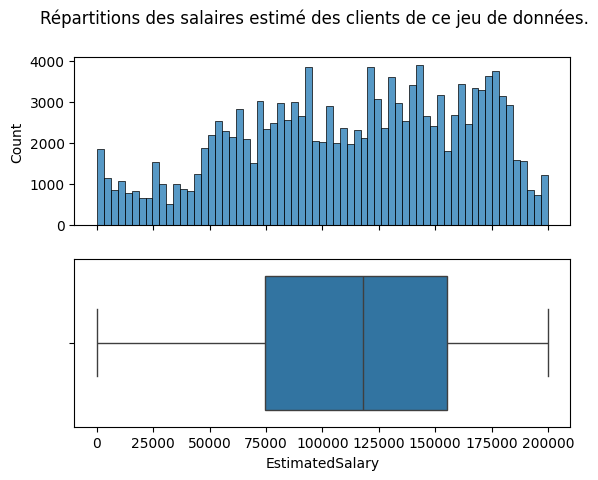

count    143579.000000
mean     112530.072465
std       50301.718378
min          11.580000
25%       74580.800000
50%      117931.100000
75%      155149.685000
max      199992.480000
Name: EstimatedSalary, dtype: float64

In [497]:
fig, ax = plt.subplots(2, 1, sharex=True)
plt.suptitle("Répartitions des salaires estimé des clients de ce jeu de données.")
sns.histplot(data=train_set, x="EstimatedSalary", ax=ax[0])
sns.boxplot(data=train_set, x="EstimatedSalary", ax=ax[1])
plt.show()
train_set["EstimatedSalary"].describe()

On voit que la moyenne des salaires estimé des clients de cette banque est de 112423 euros. Cette variable ne suit pas une loi normale. On observe aussi que le salaire minimum est de 11.58 qui correspond au smic horaire Français (environ égale à 1709 euros). Il faut savoir que les salaires estimé sont généralement des salaires mensuel et à temps plein. On voit que la plupart des salaires sont entre 40000 euros et 180000 euros ce qui est aussi bizarre pour des salaires mensuel. Il y a donc plusieurs types de salaires. On va donc dans la partie feature engineering faire cette correction. 

#II.2) Analyse multivarié.

Avant de commencé l'analyse bivarié, on peut catégoriser les variables en trois catégorie, les variables démographique, les variables monétaires et les variables de fidélité.

#II.2.1) Analyse des variables démographiques

Dans ce type variable, il y a trois variable qui sont le pays de résidence, le genre et l'âge.

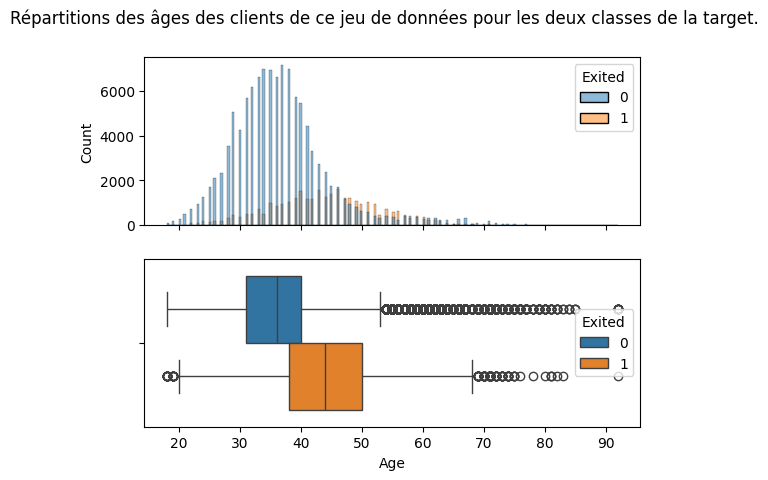

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,113129.0,36.583765,8.166737,18.0,31.0,36.0,40.0,92.0
1,30450.0,43.942890,8.981339,18.0,38.0,44.0,50.0,92.0


In [498]:
fig, ax = plt.subplots(2, 1, sharex=True)
plt.suptitle(
    "Répartitions des âges des clients de ce jeu de données pour les deux classes de la target."
)
sns.histplot(data=train_set, x="Age", hue="Exited", ax=ax[0])
sns.boxplot(data=train_set, x="Age", hue="Exited", ax=ax[1])
plt.show()
train_set.groupby("Exited")["Age"].describe()

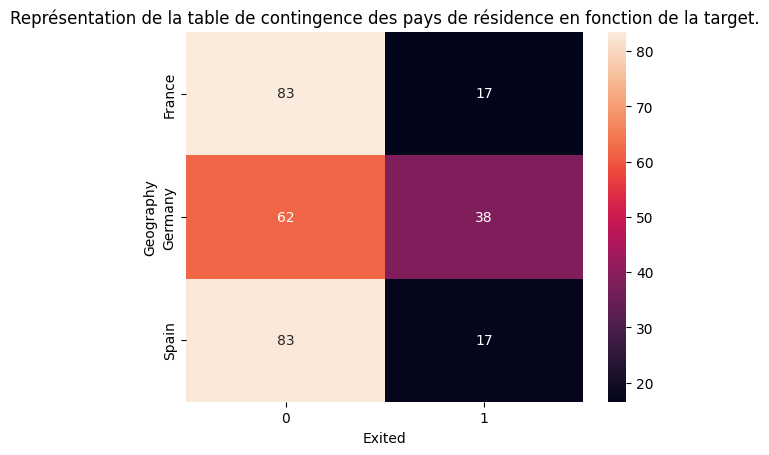

In [499]:
sns.heatmap(
    pd.crosstab(train_set["Geography"], train_set["Exited"], normalize="index") * 100,
    annot=True,
)
plt.title(
    "Représentation de la table de contingence des pays de résidence en fonction de la target."
)
plt.show()

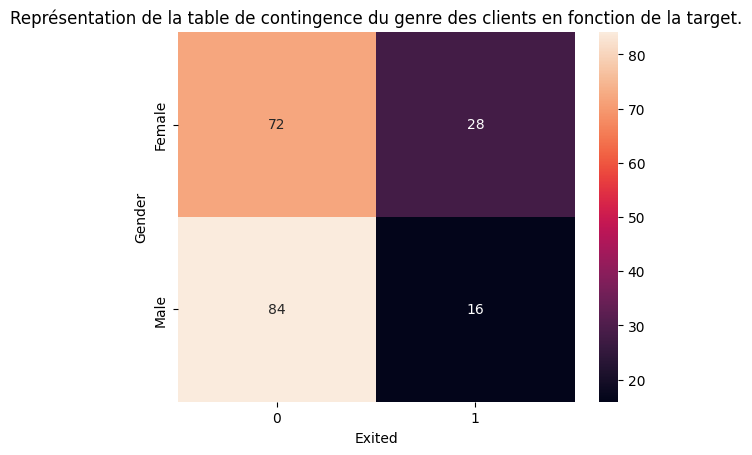

In [500]:
sns.heatmap(
    pd.crosstab(train_set["Gender"], train_set["Exited"], normalize="index") * 100,
    annot=True,
)
plt.title(
    "Représentation de la table de contingence du genre des clients en fonction de la target."
)
plt.show()

On voit qu'il y a une zone dans lequel on a plus de clients qui ont résilié que de clients qui n'ont pas résilé pour des clients qui ont entre 48 ans et 55 ans. C'est comme si il y avait un décalage entre les deux histogramme. On voit que les boxplots sont différents. On observe deux outliers à gauche de la boxplots des clients qui ont résilié. On voit que les bornes, les différents quartiles ainsi que la médiane sont différentes pour les deux boxplots. On voit que la boxplot pour les clients qui ont résilié est plus étendue que pour les clients qui n'ont pas résilié. On voit que en moyenne les clients qui ont résilié ont 44 ans et les clients qui n'ont pas résilié ont en moyenne 37 ans. Pour le pays de résidence, on voit que le taux de résiliation est plus fort pour les clients qui vive en Allemagne et pour le genre ce sont les femmes qui ont le taus de résiliation le plus fort. On voit des taux de résiliation similaires pour la France et l'Espagne. On peut simplifier cette vairiable en une variable binaire avec oneHotEncoder. On va maintenant tester les hypothéses. 

Conditions pour le test de student:

-L'âge d'un clients ne dépends pas des autres.

-Tous les clients sont issues de la même banque.

-L'âge suit bien une loi normale et on a bien plus de 30 points par classes.

-Les deux variances sont assez similaires pour utiliser un test de student.

In [501]:
print(
    "H0: Les clients qui ont résilié ont en moyenne le même âge que les clients qui n'ont pas résilié."
)

alpha = 0.02

p_value = ttest_ind(
    train_set.query("`Exited` == 0")["Age"], train_set.query("`Exited` == 1")["Age"]
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Les clients qui ont résilié ont en moyenne le même âge que les clients qui n'ont pas résilié.
Nous avons assez d'évidence pour rejeter H0


In [502]:
print("H0: Il n'y a pas de relation entre le pays de résidence et la target.")

alpha = 0.02

p_value = chi2_contingency(
    pd.crosstab(train_set["Geography"], train_set["Exited"])
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il n'y a pas de relation entre le pays de résidence et la target.
Nous avons assez d'évidence pour rejeter H0


In [503]:
print("H0: Il n'y a pas de relation entre le genre et la target.")

alpha = 0.02

p_value = chi2_contingency(pd.crosstab(train_set["Gender"], train_set["Exited"])).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il n'y a pas de relation entre le genre et la target.
Nous avons assez d'évidence pour rejeter H0


Comme on a rejeter H0 pour les trois variables démographique, on peut dire avec un seuil alpha de 2% que les clients qui ont résilié sont en moyenne plus vieux que les clients qui n'ont pas résilié, que le taux de résiliation est plus fort pour les clients qui vive en Allemagne et pour les femmes. On remarque que sur le graphique représentant l'âge, l'âge peut être considéré comme une variable discréte et par conséquent cela peut être judicieux de visualiser l'évolution du taux de résiliation en fonction de l'âge pour voir quels sont les âges avec les plus fort taux de résiliation.

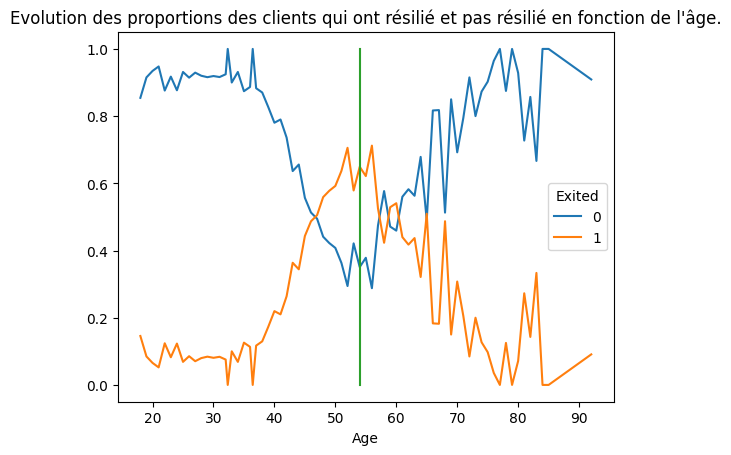

In [504]:
pd.crosstab(train_set["Age"], train_set["Exited"], normalize="index").plot()
plt.title(
    "Evolution des proportions des clients qui ont résilié et pas résilié en fonction de l'âge."
)
plt.plot([54, 54], [0, 1])
plt.show()

On remarque qu'il y a principalement quatre zone. Les clients qui ont entre 20 et 40 ans ont un taux de résiliation entre 0 et 20%, ensuite les clients qui ont entre 40 et environ 45 ans ont un taux de résiliation qui augmente jusqu'à atteindre les 50%. Entre 45 et 60 ans on a un taux de résiliation supérieur à 50% avec une petite inversion peu avant 60 ans. Ensuite le taux de résiliation diminue jusqu'à 90 ans. On en conclut que la zone avec le taux de résiliation la plus forte est la zone entre 45 et 60 ans. Il faudrat donc essayer de créer des filtres avec l'âge en faisant une discrétisation des différentes zones. On pourrait aussi centrer l'âge à la même valeur que le trait vert et ensuite mettre au carré pour créer une surface 3D dans lequel la zone la plus intéréssante sera en bas et les moin intéréssante en haut.

#II.2.2) Analyse des variables monétaires

Dans les variables monétaires on trouve le score de crédit, la balance et le salaire qui sont tous les trois des variables continues. On va donc faire d'abords une analyse bivarié puis une analyse trivarié avec des surfaces scatter.

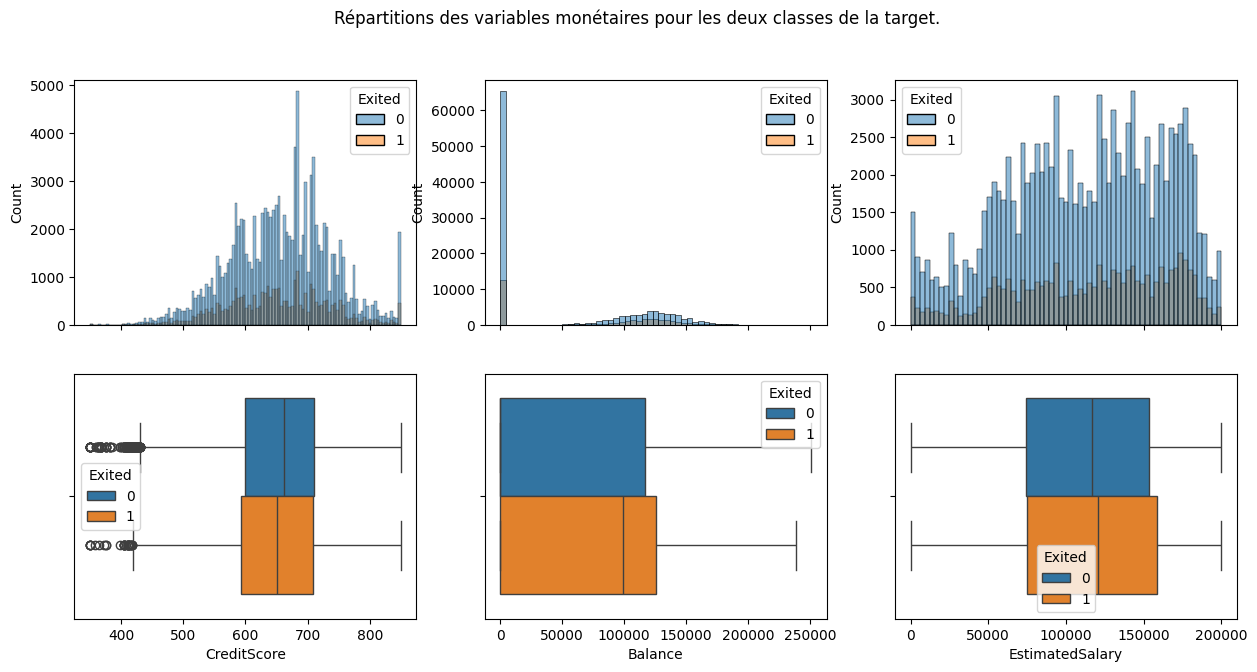

In [505]:
fig, ax = plt.subplots(2, 3, sharex="col")
fig.set_size_inches(15, 7)
plt.suptitle(
    "Répartitions des variables monétaires pour les deux classes de la target."
)
sns.histplot(data=train_set, x="CreditScore", hue="Exited", ax=ax[0, 0])
sns.boxplot(data=train_set, x="CreditScore", hue="Exited", ax=ax[1, 0])
sns.histplot(data=train_set, x="Balance", hue="Exited", ax=ax[0, 1])
sns.boxplot(data=train_set, x="Balance", hue="Exited", ax=ax[1, 1])
sns.histplot(data=train_set, x="EstimatedSalary", hue="Exited", ax=ax[0, 2])
sns.boxplot(data=train_set, x="EstimatedSalary", hue="Exited", ax=ax[1, 2])
plt.show()

In [506]:
train_set.groupby("Exited")["CreditScore"].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,113129.0,657.532136,79.899437,350.0,599.0,662.0,711.0,850.0
1,30450.0,652.249031,81.221163,350.0,593.0,651.0,709.0,850.0


In [507]:
train_set.groupby("Exited")["Balance"].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,113129.0,51274.230558,62196.885812,0.0,0.0,0.00,116811.12,250898.09
1,30450.0,71358.363247,62606.860862,0.0,0.0,98959.19,125521.18,238387.56


In [508]:
train_set.query("`Balance` != 0").groupby("Exited")["Balance"].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,47803.0,121343.899521,25541.298733,3768.69,104154.250,122359.50,138023.520,250898.09
1,17858.0,121674.440635,23686.386782,3768.69,106920.255,121874.89,135927.445,238387.56


In [509]:
train_set.groupby("Exited")["EstimatedSalary"].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,113129.0,112024.082699,50228.170190,11.58,74287.53,116971.05,153727.32,199992.48
1,30450.0,114409.944918,50530.496339,11.58,74898.80,120893.77,158830.36,199992.48


On ne voit aucune séparation entre les deux classes de la target dans les trois histogrammes et pour les trois variables les boxplots des deux classes de la target sont similaires et superposé. On voit que en moyenne les clients qui ont résilié sont moins fiable que les clients qui n'ont pas résilié. On voit une diférence dans les moyennes de balances beaucoup plus grande qui est due au fait qu'il y a une plus petites différences d'effectifs de clients qui ont résilié entre les balances différents de 0 et égale à 0 que ceux qui n'ont pas résilié. Par contre si on prend seulement les balances différents de 0, les moyennes deviennent tous de suites similaires. Pour le salaire, on voit qu'il y a des valeurs irréalistes mais le sont-elle réellement. En vrai on peut se poser la question est-ce-que certaines valeurs ne sont pas exprimé par erreur en kilos euros et les autres en euros. Cela pourrait créer une variable de salaire annuelle. On fera la correction durant le feature engineering. On va maintenant faire des tests d'hypothéses mais comme la balance est une suit une loi normale seulement sans prendre en compte les balance égale à 0, on va faire un test d'hypothése uniquement sur les balance différent de 0 et comme le salaire ne suit pas une loi normale, on ne pourras pas tester l'hypothése avec un test de student. On fera le test dans l'étapes de features engineering aprés correction si possible.

Conditions pour le test de student:

-Le score de crédit et la balance d'un client ne dépends pas des autres.

-Tous les clients sont issues de la même banque.

-Le score de crédit et les balances différents de 0 d'un client suit bien une loi normale et on a bien plus de 30 points par classes.

-Les deux variances pour le score de crédit et les balances différents de 0 sont assez similaires pour utiliser un test de student.

In [510]:
print(
    "H0: Les clients qui ont résilié ont en moyenne le même score de crédit que les clients qui n'ont pas résilié."
)

alpha = 0.02

p_value = ttest_ind(
    train_set.query("`Exited` == 0")["CreditScore"],
    train_set.query("`Exited` == 1")["CreditScore"],
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Les clients qui ont résilié ont en moyenne le même score de crédit que les clients qui n'ont pas résilié.
Nous avons assez d'évidence pour rejeter H0


In [511]:
print(
    "H0: Les clients qui ont résilié et qui ont une balance différents de 0 ont en moyenne la même balance que les clients qui n'ont pas résilié."
)

alpha = 0.02

p_value = ttest_ind(
    train_set.query("`Exited` == 0 and `Balance` != 0")["Balance"],
    train_set.query("`Exited` == 1 and `Balance` != 0")["Balance"],
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Les clients qui ont résilié et qui ont une balance différents de 0 ont en moyenne la même balance que les clients qui n'ont pas résilié.
Nous n'avons pas assez d'évidence pour rejeter H0.


On a rejeter l'hypothése H0 pour le score de crédit mais pas pour la balance différent de 0. On peut donc dire avec un seuil alpha de 2% que les clients qui ont résilié sont en moyenne moins fiable que les clients qui n'ont pas résilié et que les clients qui ont résilié et qui ont une balance différents de 0 ont en moyenne la même balance que les clients qui n'ont pas résilié. Malgré qu'il y a une différences dans les moyennes, il n'y a aucune séparation dans les répartitions. On remarque que la boxplot des clients qui ont résilié est légérements décaler vers la gauche par rapport à la boxplots des clients qui n'ont pas résilié. On voit ce décalage avec la borne inférieur, le premier quartile et la médiane puis cette différence diminue avec le troisiéme quartile. C'est-à-dire que la différence est plus forte pour des valeurs inférieur à la médiane. Maintenant comme il y a uniquement des variables continues, on va regarder les surfaces scatter.

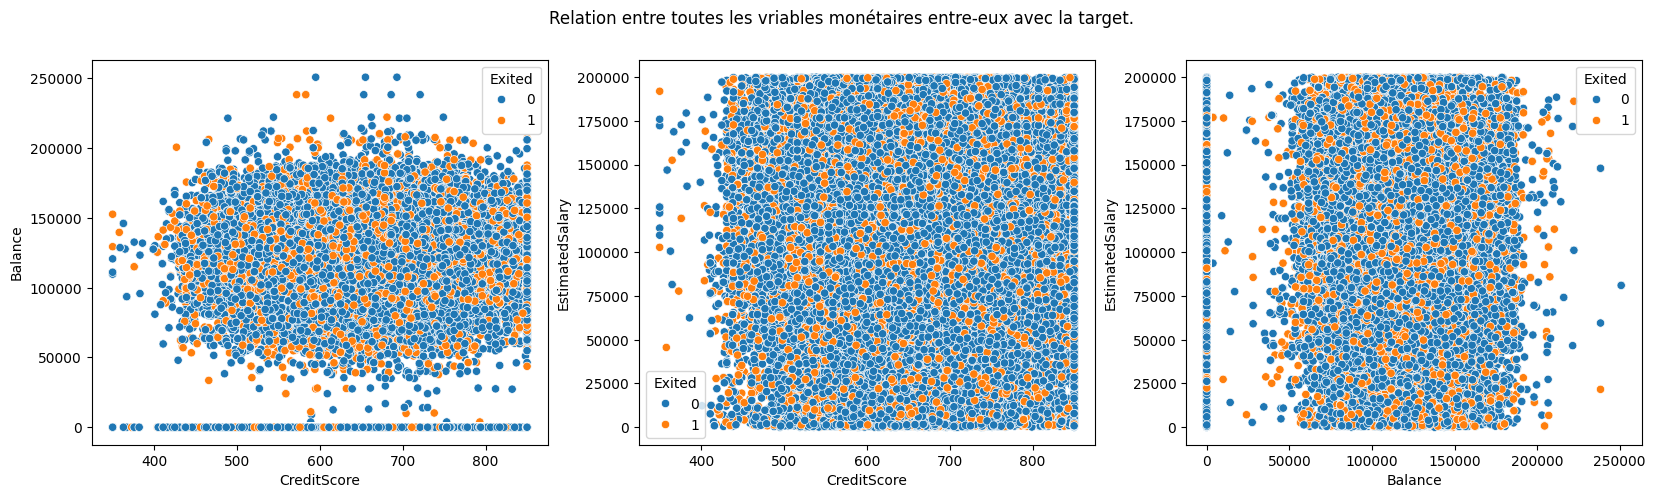

In [512]:
fig, ax = plt.subplots(1, 3)
fig.set_size_inches(20, 5)
plt.suptitle("Relation entre toutes les vriables monétaires entre-eux avec la target.")
sns.scatterplot(data=train_set, x="CreditScore", y="Balance", hue="Exited", ax=ax[0])
sns.scatterplot(
    data=train_set, x="CreditScore", y="EstimatedSalary", hue="Exited", ax=ax[1]
)
sns.scatterplot(
    data=train_set, x="Balance", y="EstimatedSalary", hue="Exited", ax=ax[2]
)
plt.show()

On ne voit aucune surface séparable. Ce qui peut être intéressant est de regarder le taux de résiliation pour les balances égale et différents de 0.  

In [513]:
train_set.query("`Balance` == 0")["Exited"].value_counts(normalize=True)

Exited
0    0.838394
1    0.161606
Name: proportion, dtype: float64

In [514]:
train_set.query("`Balance` != 0")["Exited"].value_counts(normalize=True)

Exited
0    0.728027
1    0.271973
Name: proportion, dtype: float64

On voit que le taux de résiliation sont significativement supérieur pour les balances différentes de 0. On pourrat utiliser une version binaire de la balance. Par conséquent on va juste utiliser la balance en la transformant en variable binaire.

#II.2.3) Analyse des variables de fidélités

On compte quatre variables de fidélité qui sont la Tenure, le nombre de produit, la possession d'une carte de crédit et lestatus d'activité.

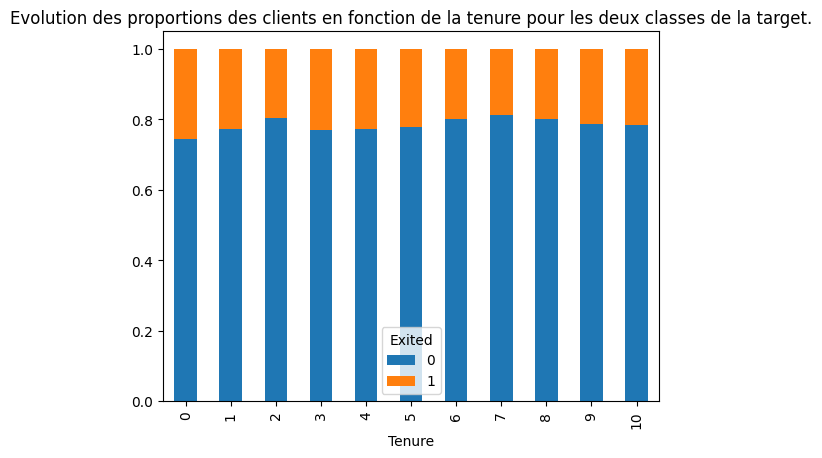

Exited,0,1
Tenure,,
0,0.744133,0.255867
1,0.772512,0.227488
2,0.805023,0.194977
3,0.771265,0.228735
4,0.772563,0.227437
5,0.779832,0.220168
6,0.802712,0.197288
7,0.811684,0.188316
8,0.800223,0.199777


In [515]:
pd.crosstab(train_set["Tenure"], train_set["Exited"], normalize="index").plot(
    kind="bar", stacked=True
)
plt.title(
    "Evolution des proportions des clients en fonction de la tenure pour les deux classes de la target."
)
plt.show()

pd.crosstab(train_set["Tenure"], train_set["Exited"], normalize="index")

In [516]:
pd.crosstab(train_set["NumOfProducts"], train_set["Exited"], normalize="index")

Exited,0,1
NumOfProducts,,
1,0.651758,0.348242
2,0.939673,0.060327
3,0.116335,0.883665
4,0.131188,0.868812


In [517]:
pd.crosstab(train_set["HasCrCard"], train_set["Exited"], normalize="index")

Exited,0,1
HasCrCard,,
0.0,0.771732,0.228268
1.0,0.793201,0.206799


In [518]:
pd.crosstab(train_set["IsActiveMember"], train_set["Exited"], normalize="index")

Exited,0,1
IsActiveMember,,
0.0,0.702321,0.297679
1.0,0.874625,0.125375


On voit que le taux de résiliation est maximal pour les clients qui ont un nombre de produit strictement supérieur à 2 et qui ne sont pas actif. On voit que le taux de résiliation est vraiment similaires en fonction de la possession d'une carte de crédit. On voit sur la figure que le taux de résiliation est presque constant en fonction de la tenure. On voit aussi que pour des nombres de produits 3 et 4,  les taux de churn sont similaires et par conséquent on peut simplifier en combinant les nombres de produits 3 et 4. Même si sur le graphique on voit que le taux de résiliation reste relativement constant en fonction de la tenure, dans la table de contingence on voit qu'il y a pour une tenure de 0 un taux de résiliation 26% et pour les tenures 1, 3, 4, 5, 9 et 10 on a un taux aux alentour de 21% à 23% et pour les autres tenure on a des taux inférieur à 20% et donc on peut créer trois groupe avec cette variable, le tenure 0 tous seul, les tenures avec des taux de résiliation entre 21% à 23% et les tenures avec les taux de résiliation inférieur à 20%. On va maintenant tester les relations.

In [519]:
print("H0: Il n'y a pas de relation entre la tenure et la target.")

alpha = 0.02

p_value = chi2_contingency(pd.crosstab(train_set["Tenure"], train_set["Exited"])).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il n'y a pas de relation entre la tenure et la target.
Nous avons assez d'évidence pour rejeter H0


In [520]:
print("H0: Il n'y a pas de relation entre le nombre de produit et la target.")

alpha = 0.02

p_value = chi2_contingency(
    pd.crosstab(train_set["NumOfProducts"], train_set["Exited"])
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il n'y a pas de relation entre le nombre de produit et la target.
Nous avons assez d'évidence pour rejeter H0


In [521]:
print(
    "H0: Il n'y a pas de relation entre la possession d'une carte de crédit et la target."
)

alpha = 0.02

p_value = chi2_contingency(
    pd.crosstab(train_set["HasCrCard"], train_set["Exited"])
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il n'y a pas de relation entre la possession d'une carte de crédit et la target.
Nous avons assez d'évidence pour rejeter H0


In [522]:
print("H0: Il n'y a pas de relation entre le status d'activité et la target.")

alpha = 0.02

p_value = chi2_contingency(
    pd.crosstab(train_set["IsActiveMember"], train_set["Exited"])
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il n'y a pas de relation entre le status d'activité et la target.
Nous avons assez d'évidence pour rejeter H0


On a rejeter H0 pour toutes les variables de fidélité. Cela veut dire que même la petite différence de taux de résiliation pour la variable de la possession d'une carte crédit est significatif. On va donc la prendre aussi.

#II.2.4) Relation entre les variables monétaires et l'âge.

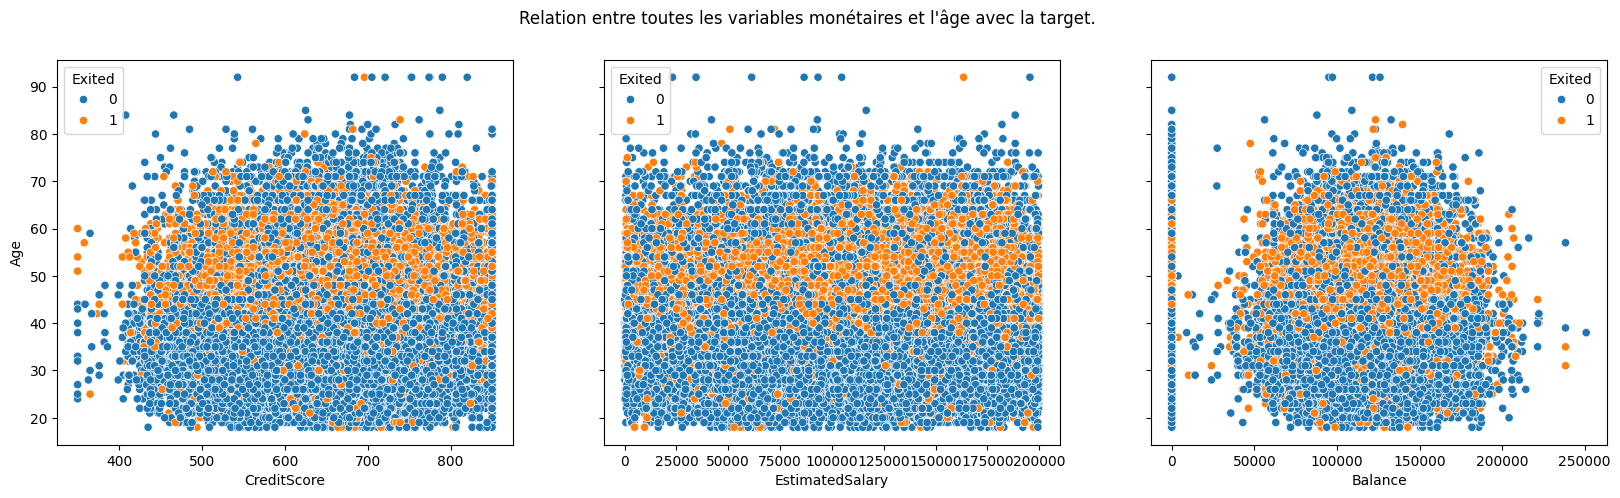

In [523]:
fig, ax = plt.subplots(1, 3, sharey=True)
fig.set_size_inches(20, 5)
plt.suptitle("Relation entre toutes les variables monétaires et l'âge avec la target.")
sns.scatterplot(data=train_set, x="CreditScore", y="Age", hue="Exited", ax=ax[0])
sns.scatterplot(data=train_set, x="EstimatedSalary", y="Age", hue="Exited", ax=ax[1])
sns.scatterplot(data=train_set, x="Balance", y="Age", hue="Exited", ax=ax[2])
plt.show()

On ne voit aucune surface séparable mais on voit que le clients qui ont résilié sont majoritairement dans un intervalles d'âges entre 40 ans et 70 ans qui correspond à la zone du graphique qui montre le taux de résiliation et de non résiliation en fonction de l'age. En conclusion, toutes les variables peuvent être importantes selon les tests d'hypothéses même si avec beaucoup de variables on observe rien d'intéréssant. Pour le premier modéle on va utiliser la surface avec le score de crédit et l'âge.

#III) Préprocéssing

#III.1) Nettoyage des données et préparation des données.

Commençons par le nettoyage des données.

In [524]:
train_set.isna().value_counts()

ID     CustomerId  Surname  CreditScore  Geography  Gender  Age    Tenure  Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Exited
False  False       False    False        False      False   False  False   False    False          False      False           False            False     143579
Name: count, dtype: int64

On voit qu'il n'y a pas de valeur vide dans le jeu de train. Durant l'analyse précédente on n'a pas vue d'outliers vraiment significatifs.

In [525]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn import set_config
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score

X_train_set = train_set.drop("Exited", axis=1)
y_train_set = train_set["Exited"]
set_config(transform_output="pandas")

On va miantenant préparer les données en simplifiant les variables simplifiable et en discrétisant les variables continues. Puis on analysera les intéractions entre les variables discrétes pour créer de nouveau filtre qu'on encodera dans la section suivante. 

a) Correction du salaire

On va d'abords corriger le salaire.

In [526]:
X_train_set_copy = X_train_set.copy()


class SalarySMICScaler(BaseEstimator, TransformerMixin):
    """
    Corrige EstimatedSalary selon le SMIC (2025) de chaque pays
    et les facteurs 10^k possibles (1, 10, 100, 1 000, 10 000).

    - Ajoute la colonne  EstSalary_clean   (float64)
    - Ajoute la colonne  ScaleFactor       (int16)
    - Conserve EstimatedSalary d’origine
    """

    # constantes internes (aucune option exposée)
    _SMIC = {"France": 21624, "Germany": 25932, "Spain": 16572}
    _FACTORS = (1, 10, 100, 1_000, 10_000)

    def fit(self, X, y=None):
        # Pas d'apprentissage ; juste la signature API
        return self

    @staticmethod
    def _fix_one(salary: float, geo: str):
        """Renvoie (salary_corrigé, facteur_appliqué)."""
        smic = SalarySMICScaler._SMIC.get(geo, min(SalarySMICScaler._SMIC.values()))
        for f in SalarySMICScaler._FACTORS:
            scaled = salary * f
            if smic <= scaled:
                return scaled, f
        return salary, 1  # aucune mise à l'échelle trouvée

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("SalarySMICScaler attend un DataFrame pandas.")

        # application ligne par ligne
        scaled, factors = zip(
            *X[["EstimatedSalary", "Geography"]].apply(
                lambda r: self._fix_one(r["EstimatedSalary"], r["Geography"]), axis=1
            )
        )

        X_out = X.copy()
        X_out["EstSalary_clean"] = np.asarray(scaled, dtype=np.float64)
        X_out["ScaleFactor"] = np.asarray(factors, dtype=np.int16)
        return X_out


X_train_set_copy = SalarySMICScaler().fit_transform(X_train_set_copy)
X_train_set_copy

,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,EstSalary_clean,ScaleFactor
0,37765,15794860,Ch'eng,627,France,Male,28.0,7,131694.04,1,1.0,1.0,161205.61,161205.61,1
1,130453,15728005,Hargreaves,597,France,Male,34.0,2,0.00,2,0.0,1.0,181419.29,181419.29,1
2,77297,15686810,Ts'ui,724,France,Male,39.0,7,0.00,2,1.0,1.0,100862.54,100862.54,1
3,40858,15760244,Trevisano,663,Germany,Female,56.0,5,118577.24,3,1.0,0.0,61164.45,61164.45,1
4,19804,15810563,French,627,France,Female,33.0,5,0.00,2,1.0,1.0,103737.82,103737.82,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143574,97639,15759915,Onwumelu,559,Germany,Male,45.0,3,111634.29,1,1.0,1.0,103349.74,103349.74,1
143575,95939,15769974,Shih,597,Germany,Male,41.0,10,119182.73,1,0.0,0.0,121299.14,121299.14,1
143576,152315,15592028,Hsiao,576,Spain,Male,31.0,6,127299.56,1,1.0,1.0,57569.89,57569.89,1
143577,117952,15804009,Ch'ang,751,France,Female,27.0,4,90721.11,1,0.0,0.0,84496.78,84496.78,1


In [527]:
X_train_set_copy["EstSalary_clean"].describe()

count    143579.000000
mean     117703.361556
std       46036.072086
min       16618.760000
25%       80575.440000
50%      121299.140000
75%      157871.550000
max      258878.900000
Name: EstSalary_clean, dtype: float64

In [528]:
X_train_set_copy.groupby(y_train_set)["EstSalary_clean"].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,113129.0,117122.825042,45943.375127,16618.76,80178.54,120961.30,156768.68,258878.9
1,30450.0,119860.192929,46315.904180,16644.16,82317.50,123845.68,160828.98,258878.9


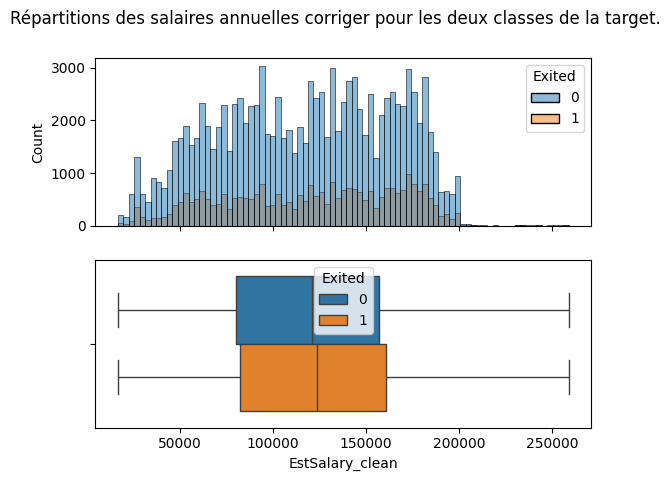

In [529]:
fig, ax = plt.subplots(2, 1, sharex="col")
plt.suptitle(
    "Répartitions des salaires annuelles corriger pour les deux classes de la target."
)
sns.histplot(data=X_train_set_copy, x="EstSalary_clean", hue=y_train_set, ax=ax[0])
sns.boxplot(data=X_train_set_copy, x="EstSalary_clean", hue=y_train_set, ax=ax[1])
plt.show()

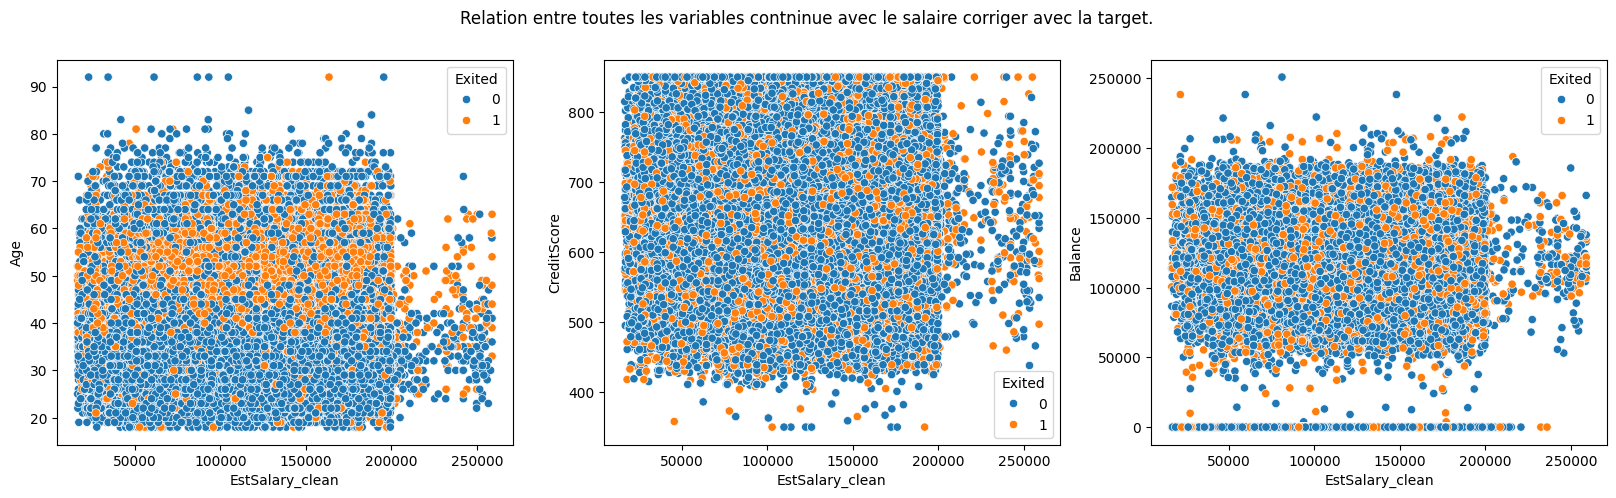

In [530]:
fig, ax = plt.subplots(1, 3, sharex=True)
fig.set_size_inches(20, 5)
plt.suptitle(
    "Relation entre toutes les variables contninue avec le salaire corriger avec la target."
)
sns.scatterplot(
    data=X_train_set_copy, x="EstSalary_clean", y="Age", hue=y_train_set, ax=ax[0]
)
sns.scatterplot(
    data=X_train_set_copy,
    x="EstSalary_clean",
    y="CreditScore",
    hue=y_train_set,
    ax=ax[1],
)
sns.scatterplot(
    data=X_train_set_copy, x="EstSalary_clean", y="Balance", hue=y_train_set, ax=ax[2]
)
plt.show()

On voit juste que le salaire ne suit pas totalement une loi normale mais on peut quand même essayer de faire un test d'hypothéése. Sinon il n'y a pas grand chose d'autre à dire.

In [531]:
print(
    "H0: Les clients qui ont résilié ont en moyenne le même salaire annuelle que les clients qui n'ont pas résilié."
)

alpha = 0.02
X_train_hypo_test = X_train_set_copy.copy()
X_train_hypo_test["Exited"] = y_train_set

p_value = ttest_ind(
    X_train_hypo_test.query("`Exited` == 1")["EstSalary_clean"],
    X_train_hypo_test.query("`Exited` == 0")["EstSalary_clean"],
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Les clients qui ont résilié ont en moyenne le même salaire annuelle que les clients qui n'ont pas résilié.
Nous avons assez d'évidence pour rejeter H0


Comme on a réussie à rejeter H0, on peut donc dire avec un seuil de 2% qu'il y a une différence significatif dans les moyennes des salaires des deux classes de la target.

b) Discrétisation des variable continue

Pour le score de crédit et le salaire on va utiliser KBinsDiscretizer. Pour le score de crédit on va créer 3 niveau avec une largeur identique qui correspondra à des niveaux de score de type mauvais, moyen et bon. Pour le salaire on va créer 5 groupes aussi de largeur identiques.

In [532]:
class PreparationDiscretisationTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        # Apprendre les paramètres à partir de X si nécessaire
        return self

    def transform(self, X, y=None):
        X["CreditScoreDiscret"] = X["CreditScore"]
        X["EstSalary_cleanDiscret"] = X["EstSalary_clean"]
        X["AgeDiscret"] = X["Age"]
        return X


KBindiscretizer = ColumnTransformer(
    [
        (
            "DiscretizerCredit",
            KBinsDiscretizer(
                n_bins=10, strategy="uniform", encode="ordinal", random_state=42
            ),
            ["CreditScoreDiscret", "EstSalary_cleanDiscret", "AgeDiscret"],
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)

discretizer = make_pipeline(PreparationDiscretisationTransformer(), KBindiscretizer)

In [533]:
X_discretize = discretizer.fit_transform(X_train_set_copy)
X_discretize

,CreditScoreDiscret,EstSalary_cleanDiscret,AgeDiscret,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,EstSalary_clean,ScaleFactor
0,5.0,5.0,1.0,37765,15794860,Ch'eng,627,France,Male,28.0,7,131694.04,1,1.0,1.0,161205.61,161205.61,1
1,4.0,6.0,2.0,130453,15728005,Hargreaves,597,France,Male,34.0,2,0.00,2,0.0,1.0,181419.29,181419.29,1
2,7.0,3.0,2.0,77297,15686810,Ts'ui,724,France,Male,39.0,7,0.00,2,1.0,1.0,100862.54,100862.54,1
3,6.0,1.0,5.0,40858,15760244,Trevisano,663,Germany,Female,56.0,5,118577.24,3,1.0,0.0,61164.45,61164.45,1
4,5.0,3.0,2.0,19804,15810563,French,627,France,Female,33.0,5,0.00,2,1.0,1.0,103737.82,103737.82,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143574,4.0,3.0,3.0,97639,15759915,Onwumelu,559,Germany,Male,45.0,3,111634.29,1,1.0,1.0,103349.74,103349.74,1
143575,4.0,4.0,3.0,95939,15769974,Shih,597,Germany,Male,41.0,10,119182.73,1,0.0,0.0,121299.14,121299.14,1
143576,4.0,1.0,1.0,152315,15592028,Hsiao,576,Spain,Male,31.0,6,127299.56,1,1.0,1.0,57569.89,57569.89,1
143577,8.0,2.0,1.0,117952,15804009,Ch'ang,751,France,Female,27.0,4,90721.11,1,0.0,0.0,84496.78,84496.78,1


In [534]:
pd.crosstab(X_discretize["CreditScoreDiscret"], y_train_set, normalize="index")

Exited,0,1
CreditScoreDiscret,,
0.0,0.796296,0.203704
1.0,0.762155,0.237845
2.0,0.778612,0.221388
3.0,0.750695,0.249305
4.0,0.775856,0.224144
5.0,0.776104,0.223896
6.0,0.806717,0.193283
7.0,0.797168,0.202832
8.0,0.795114,0.204886


In [535]:
pd.crosstab(X_discretize["EstSalary_cleanDiscret"], y_train_set, normalize="index")

Exited,0,1
EstSalary_cleanDiscret,,
0.0,0.822083,0.177917
1.0,0.779407,0.220593
2.0,0.804420,0.195580
3.0,0.800984,0.199016
4.0,0.784682,0.215318
5.0,0.786724,0.213276
6.0,0.768684,0.231316
7.0,0.777858,0.222142
8.0,0.675676,0.324324


In [536]:
pd.crosstab(X_discretize["AgeDiscret"], y_train_set, normalize="index")

Exited,0,1
AgeDiscret,,
0.0,0.909047,0.090953
1.0,0.919784,0.080216
2.0,0.870369,0.129631
3.0,0.650575,0.349425
4.0,0.390518,0.609482
5.0,0.459224,0.540776
6.0,0.702029,0.297971
7.0,0.838558,0.161442
8.0,0.888889,0.111111


On voit qu'on peut simplifier les trois variables.

In [537]:
class SimplifiedCreditScoreTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        # Apprendre les paramètres à partir de X si nécessaire
        return self

    def transform(self, X, y=None):
        X["CreditScoreDiscret"] = X["CreditScoreDiscret"].replace(
            {(2, 4, 5, 6, 7, 8, 9): 0, 3: 1}
        )
        return X


X_discretize = SimplifiedCreditScoreTransformer().fit_transform(X_discretize)
pd.crosstab(X_discretize["CreditScoreDiscret"], y_train_set, normalize="index")

Exited,0,1
CreditScoreDiscret,,
0.0,0.790679,0.209321
1.0,0.751556,0.248444


En simplifiant le score de crédit discrétiser on arrive à créer une différence de taux de résiliation entre les deux groupes de 5%. Testons la relation en prenant un seuil alpha de 2%

In [538]:
chi2_contingency(pd.crosstab(X_discretize["CreditScoreDiscret"], y_train_set)).pvalue

np.float64(1.8748456713182818e-20)

La p_value est largement en dessous de 2% donc il n'y a pas de doute, il y a bien une relation entre cette variable et la target. Pasons au salaire.

In [539]:
class SimplifiedSalaryTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        # Apprendre les paramètres à partir de X si nécessaire
        return self

    def transform(self, X, y=None):
        X["EstSalary_cleanDiscret"] = X["EstSalary_cleanDiscret"].replace(
            {(1, 2, 3, 4, 5, 6, 7): 0, (8, 9): 1}
        )
        return X


X_discretize = SimplifiedSalaryTransformer().fit_transform(X_discretize)
pd.crosstab(X_discretize["EstSalary_cleanDiscret"], y_train_set, normalize="index")

Exited,0,1
EstSalary_cleanDiscret,,
0.0,0.788170,0.211830
1.0,0.668896,0.331104


On voit des taux de résiliation complêteùent différent. On va maintenant tester la relation.

In [540]:
chi2_contingency(
    pd.crosstab(X_discretize["EstSalary_cleanDiscret"], y_train_set)
).pvalue

np.float64(6.720371787931352e-07)

On voit que la p_value est bien en dessous de 2%. ON peut donc dire qu'il y a bien une relation. On va donc garder cette variable. Passons à l'âge.

In [541]:
class SimplifiedAgeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        # Apprendre les paramètres à partir de X si nécessaire
        return self

    def transform(self, X, y=None):
        X["AgeDiscret"] = X["AgeDiscret"].replace(
            {
                (1, 9): 0,
                8: 2,
            }
        )
        return X


X_discretize = SimplifiedAgeTransformer().fit_transform(X_discretize)
pd.crosstab(X_discretize["AgeDiscret"], y_train_set, normalize="index")

Exited,0,1
AgeDiscret,,
0.0,0.918034,0.081966
2.0,0.870389,0.129611
3.0,0.650575,0.349425
4.0,0.390518,0.609482
5.0,0.459224,0.540776
6.0,0.702029,0.297971
7.0,0.838558,0.161442


On à un age discretiser qui contient pour chaque catégorie un taux de résiliation différent. Testons la relation.

In [542]:
chi2_contingency(pd.crosstab(X_discretize["AgeDiscret"], y_train_set)).pvalue

np.float64(0.0)

On voit que effectivement la p_value est strictement null est par conséquent il y a donc une relation entre les deux variables. Simplifions maintenant la tenure.

In [543]:
pd.crosstab(X_discretize["Tenure"], y_train_set, normalize="index")

Exited,0,1
Tenure,,
0,0.744133,0.255867
1,0.772512,0.227488
2,0.805023,0.194977
3,0.771265,0.228735
4,0.772563,0.227437
5,0.779832,0.220168
6,0.802712,0.197288
7,0.811684,0.188316
8,0.800223,0.199777


In [544]:
class SimplifiedTenureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        # Apprendre les paramètres à partir de X si nécessaire
        return self

    def transform(self, X, y=None):
        X["Tenure"] = X["Tenure"].replace(
            {
                (2, 3, 4, 5, 6, 7, 8, 9, 10): 1,
            }
        )
        return X


X_discretize = SimplifiedTenureTransformer().fit_transform(X_discretize)
pd.crosstab(X_discretize["Tenure"], y_train_set, normalize="index")

Exited,0,1
Tenure,,
0,0.744133,0.255867
1,0.789288,0.210712


On observe que la tenure simplifier contient deux groupe avec des taux de résiliation différents. Testons la relation.

In [545]:
chi2_contingency(pd.crosstab(X_discretize["Tenure"], y_train_set)).pvalue

np.float64(8.526150334394591e-13)

La valeur de la p_value est inférieur au seuil de 2% et par conséquent il y a bien une relation entre les deux variables. Passons à la balance.

In [546]:
class BinaryBalanceTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        # Apprendre les paramètres à partir de X si nécessaire
        return self

    def transform(self, X, y=None):
        X["BinaryBalance"] = np.select([X["Balance"] != 0], [1], default=0)
        return X


X_discretize = BinaryBalanceTransformer().fit_transform(X_discretize)
pd.crosstab(X_discretize["BinaryBalance"], y_train_set, normalize="index")

Exited,0,1
BinaryBalance,,
0,0.838394,0.161606
1,0.728027,0.271973


In [547]:
chi2_contingency(pd.crosstab(X_discretize["BinaryBalance"], y_train_set)).pvalue

np.float64(0.0)

Sans surprise il y a bien une relation.

In [548]:
class SimplifiedNumOfProductsTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        # Apprendre les paramètres à partir de X si nécessaire
        return self

    def transform(self, X, y=None):
        X["NumOfProducts"] = X["NumOfProducts"].replace({4: 3})
        return X


X_discretize = SimplifiedNumOfProductsTransformer().fit_transform(X_discretize)
pd.crosstab(X_discretize["NumOfProducts"], y_train_set, normalize="index")

Exited,0,1
NumOfProducts,,
1,0.651758,0.348242
2,0.939673,0.060327
3,0.118394,0.881606


In [549]:
chi2_contingency(pd.crosstab(X_discretize["NumOfProducts"], y_train_set)).pvalue

np.float64(0.0)

Sans surprise, il y a bien une relation.

In [550]:
preparator = make_pipeline(
    SalarySMICScaler(),
    discretizer,
    SimplifiedCreditScoreTransformer(),
    SimplifiedAgeTransformer(),
    SimplifiedSalaryTransformer(),
    SimplifiedTenureTransformer(),
    BinaryBalanceTransformer(),
    SimplifiedNumOfProductsTransformer(),
)
preparator

/home/florian/Bank-churn/bankChurn/.venv/lib/python3.10/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('salarysmicscaler', SalarySMICScaler()),
                ('pipeline',
                 Pipeline(steps=[('preparationdiscretisationtransformer',
                                  PreparationDiscretisationTransformer()),
                                 ('columntransformer',
                                  ColumnTransformer(remainder='passthrough',
                                                    transformers=[('DiscretizerCredit',
                                                                   KBinsDiscretizer(encode='ordinal',
                                                                                    n_bins=10,
                                                                                    random_state=42,
                                                                                    strategy='uniform'),
                                                                   ['Credit...
                ('simplifiedcreditscoretransformer',
                 SimplifiedCreditScoreTransformer()),
                ('simplifiedagetransformer', SimplifiedAgeTransformer()),
                ('simplifiedsalarytransformer', SimplifiedSalaryTransformer()),
                ('simplifiedtenuretransformer', SimplifiedTenureTransformer()),
                ('binarybalancetransformer', BinaryBalanceTransformer()),
                ('simplifiednumofproductstransformer',
                 SimplifiedNumOfProductsTransformer())])

In [551]:
column_prepare = preparator.fit_transform(X_discretize)
column_prepare

,CreditScoreDiscret,EstSalary_cleanDiscret,AgeDiscret,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,EstSalary_clean,ScaleFactor,BinaryBalance
0,0.0,0.0,0.0,37765,15794860,Ch'eng,627,France,Male,28.0,1,131694.04,1,1.0,1.0,161205.61,161205.61,1,1
1,0.0,0.0,2.0,130453,15728005,Hargreaves,597,France,Male,34.0,1,0.00,2,0.0,1.0,181419.29,181419.29,1,0
2,0.0,0.0,2.0,77297,15686810,Ts'ui,724,France,Male,39.0,1,0.00,2,1.0,1.0,100862.54,100862.54,1,0
3,0.0,0.0,5.0,40858,15760244,Trevisano,663,Germany,Female,56.0,1,118577.24,3,1.0,0.0,61164.45,61164.45,1,1
4,0.0,0.0,2.0,19804,15810563,French,627,France,Female,33.0,1,0.00,2,1.0,1.0,103737.82,103737.82,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143574,0.0,0.0,3.0,97639,15759915,Onwumelu,559,Germany,Male,45.0,1,111634.29,1,1.0,1.0,103349.74,103349.74,1,1
143575,0.0,0.0,3.0,95939,15769974,Shih,597,Germany,Male,41.0,1,119182.73,1,0.0,0.0,121299.14,121299.14,1,1
143576,0.0,0.0,0.0,152315,15592028,Hsiao,576,Spain,Male,31.0,1,127299.56,1,1.0,1.0,57569.89,57569.89,1,1
143577,0.0,0.0,0.0,117952,15804009,Ch'ang,751,France,Female,27.0,1,90721.11,1,0.0,0.0,84496.78,84496.78,1,1


#III.2) Encoding

On voit qu'il y a trois variables à encoder qui sont le nom, le pays de résidence et le genre mais on va seulement encoder le pays de résidence et le genre car on supprimera le nom. La variable du genre est une variable binaire et le pays est une variable non ordinal et par conséquent on utilisera seulement un onehot encoder pour les deux variables. On appliquera pas drop first car on va sélectionner à la fin les meilleurs variables.

In [552]:
categorical_column = ["Geography", "Gender"]
encoder = ColumnTransformer(
    [
        (
            "Encoding_onehot",
            OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"),
            categorical_column,
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)
encoder

ColumnTransformer(remainder='passthrough',
                  transformers=[('Encoding_onehot',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Geography', 'Gender'])],
                  verbose_feature_names_out=False)

In [553]:
column_encoders = encoder.fit_transform(column_prepare)
column_encoders

,Geography_Germany,Geography_Spain,Gender_Male,CreditScoreDiscret,EstSalary_cleanDiscret,AgeDiscret,ID,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,EstSalary_clean,ScaleFactor,BinaryBalance
0,0.0,0.0,1.0,0.0,0.0,0.0,37765,15794860,Ch'eng,627,28.0,1,131694.04,1,1.0,1.0,161205.61,161205.61,1,1
1,0.0,0.0,1.0,0.0,0.0,2.0,130453,15728005,Hargreaves,597,34.0,1,0.00,2,0.0,1.0,181419.29,181419.29,1,0
2,0.0,0.0,1.0,0.0,0.0,2.0,77297,15686810,Ts'ui,724,39.0,1,0.00,2,1.0,1.0,100862.54,100862.54,1,0
3,1.0,0.0,0.0,0.0,0.0,5.0,40858,15760244,Trevisano,663,56.0,1,118577.24,3,1.0,0.0,61164.45,61164.45,1,1
4,0.0,0.0,0.0,0.0,0.0,2.0,19804,15810563,French,627,33.0,1,0.00,2,1.0,1.0,103737.82,103737.82,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143574,1.0,0.0,1.0,0.0,0.0,3.0,97639,15759915,Onwumelu,559,45.0,1,111634.29,1,1.0,1.0,103349.74,103349.74,1,1
143575,1.0,0.0,1.0,0.0,0.0,3.0,95939,15769974,Shih,597,41.0,1,119182.73,1,0.0,0.0,121299.14,121299.14,1,1
143576,0.0,1.0,1.0,0.0,0.0,0.0,152315,15592028,Hsiao,576,31.0,1,127299.56,1,1.0,1.0,57569.89,57569.89,1,1
143577,0.0,0.0,0.0,0.0,0.0,0.0,117952,15804009,Ch'ang,751,27.0,1,90721.11,1,0.0,0.0,84496.78,84496.78,1,1


#III.4) Normalisation

On va utiliser minmax avec toutes les variables discrétes.

In [554]:
normalizer = ColumnTransformer(
    [
        (
            "standard",
            StandardScaler(),
            ["Age", "CreditScore"],
        ),
        (
            "MinMax",
            MinMaxScaler(),
            [
                "NumOfProducts",
                "Geography_Germany",
                "IsActiveMember",
                "Gender_Male",
                "BinaryBalance",
                "Tenure",
                "CreditScoreDiscret",
                "EstSalary_cleanDiscret",
                "AgeDiscret",
            ],
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)
normalizer

ColumnTransformer(transformers=[('standard', StandardScaler(),
                                 ['Age', 'CreditScore']),
                                ('MinMax', MinMaxScaler(),
                                 ['NumOfProducts', 'Geography_Germany',
                                  'IsActiveMember', 'Gender_Male',
                                  'BinaryBalance', 'Tenure',
                                  'CreditScoreDiscret',
                                  'EstSalary_cleanDiscret', 'AgeDiscret'])],
                  verbose_feature_names_out=False)

In [555]:
final_column = normalizer.fit_transform(column_encoders)
final_column

,Age,CreditScore,NumOfProducts,Geography_Germany,IsActiveMember,Gender_Male,BinaryBalance,Tenure,CreditScoreDiscret,EstSalary_cleanDiscret,AgeDiscret
0,-1.143467,-0.366683,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.000000
1,-0.467158,-0.740701,0.5,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.285714
2,0.096433,0.842641,0.5,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.285714
3,2.012643,0.082138,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.714286
4,-0.579876,-0.366683,0.5,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.285714
...,...,...,...,...,...,...,...,...,...,...,...
143574,0.772742,-1.214457,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.428571
143575,0.321870,-0.740701,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.428571
143576,-0.805313,-1.002514,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.000000
143577,-1.256186,1.179257,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.000000


In [556]:
pipeline = make_pipeline(preparator, encoder, normalizer)
pipeline

/home/florian/Bank-churn/bankChurn/.venv/lib/python3.10/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('salarysmicscaler', SalarySMICScaler()),
                                 ('pipeline',
                                  Pipeline(steps=[('preparationdiscretisationtransformer',
                                                   PreparationDiscretisationTransformer()),
                                                  ('columntransformer',
                                                   ColumnTransformer(remainder='passthrough',
                                                                     transformers=[('DiscretizerCredit',
                                                                                    KBinsDiscretizer(encode='ordinal',
                                                                                                     n_bins=10,
                                                                                                     random_state=42,...
                                   verbose_feature_names_out=False)),
                ('columntransformer-2',
                 ColumnTransformer(transformers=[('standard', StandardScaler(),
                                                  ['Age', 'CreditScore']),
                                                 ('MinMax', MinMaxScaler(),
                                                  ['NumOfProducts',
                                                   'Geography_Germany',
                                                   'IsActiveMember',
                                                   'Gender_Male',
                                                   'BinaryBalance', 'Tenure',
                                                   'CreditScoreDiscret',
                                                   'EstSalary_cleanDiscret',
                                                   'AgeDiscret'])],
                                   verbose_feature_names_out=False))])

In [557]:
train_set_finale = pipeline.fit_transform(X_train_set, y_train_set)
train_set_finale

,Age,CreditScore,NumOfProducts,Geography_Germany,IsActiveMember,Gender_Male,BinaryBalance,Tenure,CreditScoreDiscret,EstSalary_cleanDiscret,AgeDiscret
0,-1.143467,-0.366683,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.000000
1,-0.467158,-0.740701,0.5,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.285714
2,0.096433,0.842641,0.5,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.285714
3,2.012643,0.082138,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.714286
4,-0.579876,-0.366683,0.5,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.285714
...,...,...,...,...,...,...,...,...,...,...,...
143574,0.772742,-1.214457,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.428571
143575,0.321870,-0.740701,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.428571
143576,-0.805313,-1.002514,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.000000
143577,-1.256186,1.179257,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.000000


#IV) Modélisation

Pour ce projet on va tester DecisionTreeClassifier.

In [558]:
model = DecisionTreeClassifier(random_state=42)
param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 5, 10, 20, 30, 40, 50],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 10],
    "splitter": ["best", "random"],
}

grisearch = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring="f1")
grisearch.fit(train_set_finale, y_train_set)
print(grisearch.best_params_)
print(grisearch.best_score_)
print(grisearch.score(train_set_finale, y_train_set))

{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 20, 'splitter': 'random'}
0.6328896930265974
0.6434241419148063


In [559]:
kaggle_test_set = pd.read_csv("test_data.csv")
kaggle_test_set.head()

,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,67897,15585246,Bancks,585,France,Female,53.0,2,0.00,2,1.0,1.0,91830.75
1,163075,15604551,Robb,606,France,Male,24.0,2,0.00,1,0.0,1.0,90876.95
2,134760,15729040,Ugochukwu,633,Germany,Male,44.0,1,118907.60,1,1.0,0.0,47777.15
3,68707,15792329,Hs?,602,Germany,Male,40.0,2,149961.99,2,1.0,1.0,82696.84
4,3428,15617166,Genovesi,645,France,Male,31.0,4,132351.29,1,1.0,0.0,151887.16


In [560]:
kaggle_test_set_finale = pipeline.transform(kaggle_test_set)
kaggle_test_set_finale

/home/florian/Bank-churn/bankChurn/.venv/lib/python3.10/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


,Age,CreditScore,NumOfProducts,Geography_Germany,IsActiveMember,Gender_Male,BinaryBalance,Tenure,CreditScoreDiscret,EstSalary_cleanDiscret,AgeDiscret
0,1.674488,-0.890308,0.5,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.571429
1,-1.594340,-0.628496,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.000000
2,0.660024,-0.291880,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.428571
3,0.209151,-0.678365,0.5,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.285714
4,-0.805313,-0.142273,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
21450,-0.354440,0.356418,0.5,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.285714
21451,0.998179,-0.104871,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.428571
21452,-0.692594,-0.616029,0.5,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.000000
21453,2.012643,0.605763,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.714286


In [561]:
best_model = grisearch.best_estimator_

ypred = best_model.predict(kaggle_test_set_finale)
ypred

array([0, 0, 1, ..., 0, 1, 0], shape=(21455,))

In [562]:
results = pd.DataFrame({"ID": kaggle_test_set["ID"], "Exited": ypred})
results.set_index("ID")

,Exited
ID,
67897,0
163075,0
134760,1
68707,0
3428,0
...,...
24790,0
152608,1
28134,0


In [563]:
results.to_csv("submission.csv")